In [1]:
import pandas as pd
import polars as pl

In [2]:
d13=pl.read_csv('d13.csv',encoding="utf8-lossy",
    ignore_errors=True)


In [25]:
d13.head()

MDR_REPORT_KEY,YEAR,FOI_TEXT,TEXT_LENGTH,BRAND_NAME,GENERIC_NAME,DEVICE_REPORT_PRODUCT_CODE,MANUFACTURER_D_NAME,DEVICE_SEQUENCE_NO,DATE_RECEIVED
i64,i64,str,i64,str,str,str,str,i64,str
2094110,2017,"""mfrs comment t…",13811,"""EPICEL (CULTUR…","""CULTURED EPIDE…","""OCE""","""GENZYME BIOSUR…",28954,"""2017/01/12"""
2296019,2015,"""it was reporte…",2058,"""NEXGEN LCCK FE…","""KNEE PROSTHESI…","""JWH""","""ZIMMER, INC.""",451705,"""2015/07/13"""
2686192,2015,"""it was reporte…",25055,"""G2 FILTER SYST…","""VENA CAVA FILT…","""DTK""","""BARD PERIPHERA…",20222,"""2015/01/09"""
2893201,2015,"""this is a supp…",2434,"""OLYMPUS EVIS E…","""DUODENOSCOPE""","""FDT""","""OLYMPUS MEDICA…",309162,"""2015/05/11"""
4068041,2015,"""cormet revisio…",467,"""CORMET RESURFA…","""METAL ON METAL…","""NXT""","""CORIN MEDICAL,…",110085,"""2015/02/13"""


In [5]:
d13.columns

['MDR_REPORT_KEY',
 'YEAR',
 'FOI_TEXT',
 'TEXT_LENGTH',
 'BRAND_NAME',
 'GENERIC_NAME',
 'DEVICE_REPORT_PRODUCT_CODE',
 'MANUFACTURER_D_NAME',
 'DEVICE_SEQUENCE_NO',
 'DATE_RECEIVED']

In [3]:
complaints_by_device = (
    d13
    .groupby(["DEVICE_REPORT_PRODUCT_CODE", "GENERIC_NAME"])
    .agg(pl.count().alias("num_complaints"))
    .sort("num_complaints", descending=True)
)



/scratch/3677707.1.cds-gpu/ipykernel_4010064/1240981541.py:3: DeprecationWarning: `groupby` is deprecated. It has been renamed to `group_by`.
  .groupby(["DEVICE_REPORT_PRODUCT_CODE", "GENERIC_NAME"])
/scratch/3677707.1.cds-gpu/ipykernel_4010064/1240981541.py:4: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  .agg(pl.count().alias("num_complaints"))


In [4]:
top_devices = complaints_by_device.head(20)
df_plot = top_devices.to_pandas()

In [33]:
top_devices

DEVICE_REPORT_PRODUCT_CODE,GENERIC_NAME,num_complaints
str,str,u32
"""DZE""","""ENDOSSEOUS DEN…",2645647
"""QBJ""","""CONTINUOUS GLU…",1737493
"""FRN""","""PUMP, INFUSION…",1427902
"""QFG""","""ALTERNATE CONT…",576471
"""OZP""","""ARTIFICIAL PAN…",413287
"""OYC""","""PUMP, INFUSION…",397805
"""OZP""","""AUTOMATED INSU…",383585
"""QFG""","""ALTERNATE CONT…",375107
"""DZE""","""IMPLANT, ENDOS…",332437


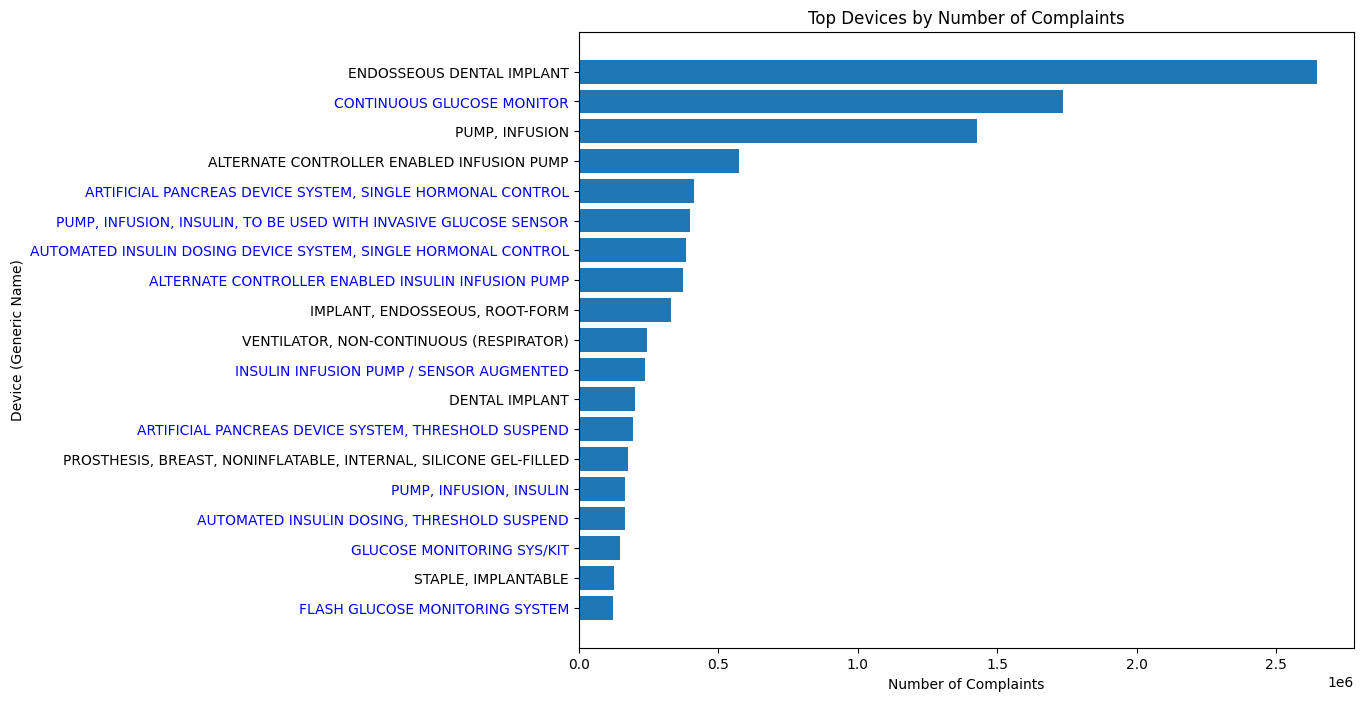

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.barh(
    df_plot["GENERIC_NAME"],
    df_plot["num_complaints"]
)

plt.xlabel("Number of Complaints")
plt.ylabel("Device (Generic Name)")
plt.title("Top Devices by Number of Complaints")

ax = plt.gca()

keywords = ["glucose", "insulin", "pancreas"]

for label in ax.get_yticklabels():
    text = label.get_text().lower()
    
    if any(word in text for word in keywords):
        label.set_color("blue")

plt.gca().invert_yaxis() 
plt.show()

/scratch/3677707.1.cds-gpu/ipykernel_4010064/2175888839.py:4: DeprecationWarning: `groupby` is deprecated. It has been renamed to `group_by`.
  .groupby(["YEAR"])
/scratch/3677707.1.cds-gpu/ipykernel_4010064/2175888839.py:5: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  .agg(pl.count().alias("num_complaints"))


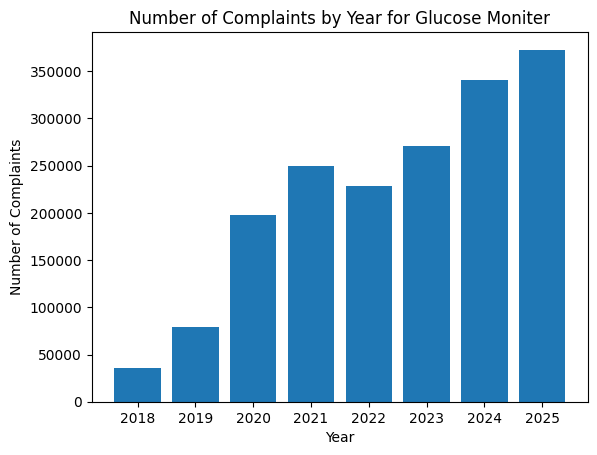

In [6]:
d13_gm=d13.filter(pl.col("DEVICE_REPORT_PRODUCT_CODE") == 'QBJ')
gm_by_year = (
    d13_gm
    .groupby(["YEAR"])
    .agg(pl.count().alias("num_complaints"))
    .sort("YEAR", descending=False)
)

gm_plot = gm_by_year.to_pandas()
plt.bar(
    gm_plot["YEAR"],
    gm_plot["num_complaints"]
)
plt.xlabel("Year")
plt.ylabel("Number of Complaints")
plt.title("Number of Complaints by Year for Glucose Moniter")
plt.show()

/scratch/3677707.1.cds-gpu/ipykernel_4010064/749873820.py:4: DeprecationWarning: `groupby` is deprecated. It has been renamed to `group_by`.
  .groupby(["YEAR"])
/scratch/3677707.1.cds-gpu/ipykernel_4010064/749873820.py:5: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  .agg(pl.count().alias("num_complaints"))


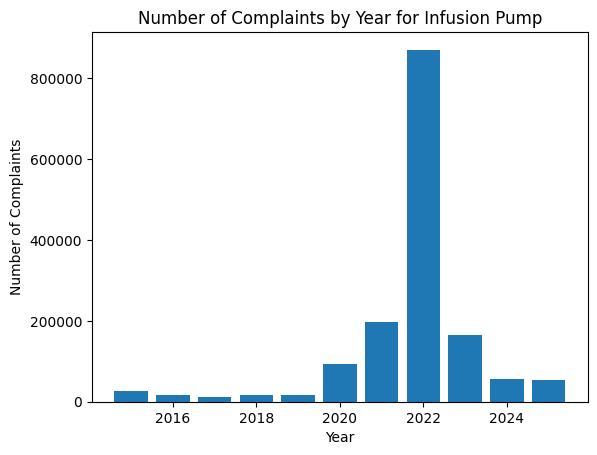

In [8]:
d13_if=d13.filter(pl.col("DEVICE_REPORT_PRODUCT_CODE") == 'FRN')
if_by_year = (
    d13_if
    .groupby(["YEAR"])
    .agg(pl.count().alias("num_complaints"))
    .sort("YEAR", descending=False)
)

if_plot = if_by_year.to_pandas()
plt.bar(
    if_plot["YEAR"],
    if_plot["num_complaints"]
)
plt.xlabel("Year")
plt.ylabel("Number of Complaints")
plt.title("Number of Complaints by Year for Infusion Pump")
plt.show()

/scratch/3677707.1.cds-gpu/ipykernel_4010064/3492177131.py:4: DeprecationWarning: `groupby` is deprecated. It has been renamed to `group_by`.
  .groupby(["YEAR"])
/scratch/3677707.1.cds-gpu/ipykernel_4010064/3492177131.py:5: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  .agg(pl.count().alias("num_complaints"))


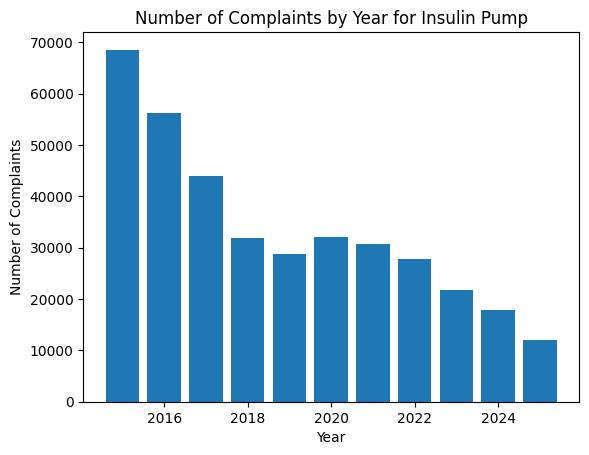

In [9]:
d13_is=d13.filter(pl.col("DEVICE_REPORT_PRODUCT_CODE") == 'LZG')
is_by_year = (
    d13_is
    .groupby(["YEAR"])
    .agg(pl.count().alias("num_complaints"))
    .sort("YEAR", descending=False)
)

is_plot = is_by_year.to_pandas()
plt.bar(
    is_plot["YEAR"],
    is_plot["num_complaints"]
)
plt.xlabel("Year")
plt.ylabel("Number of Complaints")
plt.title("Number of Complaints by Year for Insulin Pump")
plt.show()

In [10]:
d24=pl.read_csv('problem_recall_dataset.csv')


cfres_id,product_code,product_description,reason_for_recall,device_name,device_class,event_date_initiated,recall_status,similarity_score,FDA_CODE,problem_term,NCIT_CODE,IMDRF_CODE,FDA_mapped
i64,str,str,str,str,str,str,str,f64,i64,str,str,str,bool
218307,"""FNM""","""Adapt Pump, Mo…","""agiliti identi…","""Mattress, Air …","""2""","""2026-01-21""","""Open, Classifi…",0.135712,null,null,null,null,false
218406,"""KPL""","""PIE PAK Models…","""lack of 510k c…","""Colonic Irriga…","""2""","""2026-01-14""","""Open, Classifi…",0.275843,4065,"""lack of effect…","""C187247""","""A0105""",true
105069,"""LFQO""","""Magnus Hybrid …","""a component of…",null,"""nan""","""2011-09-19""","""Terminated""",0.356784,1299,"""hybrid failure…",null,null,true
105700,"""RER""","""Raymond Laser …","""raymond shippe…","""Alignment Lase…","""Unknown""","""2011-11-28""","""Terminated""",0.102701,null,null,null,null,false
131624,"""KOG""","""PKG, OBTURATOR…","""the parameters…",null,"""nan""","""2014-11-17""","""Terminated""",0.349947,1142,"""failure to cyc…","""C63187""","""A050703""",true
131797,"""KOG""","""PKG, 5MM ROTAT…","""the parameters…",null,"""nan""","""2014-11-17""","""Terminated""",0.349947,1142,"""failure to cyc…","""C63187""","""A050703""",true
131743,"""KOG""","""PKG, BLUNT FOR…","""the parameters…",null,"""nan""","""2014-11-17""","""Terminated""",0.349947,1142,"""failure to cyc…","""C63187""","""A050703""",true
131693,"""KOG""","""PKG, SCHERTEL …","""the parameters…",null,"""nan""","""2014-11-17""","""Terminated""",0.349947,1142,"""failure to cyc…","""C63187""","""A050703""",true
131625,"""KOG""","""PKG, CANNULA 5…","""the parameters…",null,"""nan""","""2014-11-17""","""Terminated""",0.349947,1142,"""failure to cyc…","""C63187""","""A050703""",true


In [22]:
test2=d24.filter(pl.col("product_code") == 'FRN')
test2

cfres_id,product_code,product_description,reason_for_recall,device_name,device_class,event_date_initiated,recall_status,similarity_score,FDA_CODE,problem_term,NCIT_CODE,IMDRF_CODE,FDA_mapped
i64,str,str,str,str,str,str,str,f64,i64,str,str,str,bool
108274,"""FRN""","""Non-DEHP Epidu…","""ambulatory adm…","""Pump, Infusion…","""2""","""2012-03-20""","""Terminated""",0.221884,null,null,null,null,false
97788,"""FRN""","""Curlin PainSma…","""infusion pumps…","""Pump, Infusion…","""2""","""2011-02-28""","""Terminated""",0.386056,1663,"""device inopera…",null,null,true
97977,"""FRN""","""ACCU-CHEK Flex…","""there is the p…","""Pump, Infusion…","""2""","""2011-02-24""","""Terminated""",0.137305,null,null,null,null,false
97979,"""FRN""","""ACCU-CHEK Flex…","""there is the p…","""Pump, Infusion…","""2""","""2011-02-24""","""Terminated""",0.137305,null,null,null,null,false
97052,"""FRN""","""Hospira Plum X…","""hospira has re…","""Pump, Infusion…","""2""","""2011-02-14""","""Terminated""",0.376812,1016,"""low audible al…","""C63049""","""A160103""",true
104072,"""FRN""","""Plum A+ Single…","""hospira has re…","""Pump, Infusion…","""2""","""2011-09-16""","""Terminated""",0.240085,null,null,null,null,false
113568,"""FRN""","""***This recall…","""this recall is…","""Pump, Infusion…","""2""","""2012-09-26""","""Terminated""",0.111418,null,null,null,null,false
74924,"""FRN""","""Stryker PainPu…","""there is a pot…","""Pump, Infusion…","""2""","""2008-11-07""","""Terminated""",0.314007,1502,"""failure to pum…","""C63165""","""A141203""",true
75724,"""FRN""","""Symbiq One-Cha…","""hypersensitivi…","""Pump, Infusion…","""2""","""2008-12-03""","""Terminated""",0.247585,null,null,null,null,false


In [30]:
complaints_df = d13.with_columns()

recalls_df = d24.with_columns(
    pl.col("event_date_initiated").str.strptime(pl.Date, "%Y-%m-%d").dt.year().alias("YEAR").cast(pl.Int64)
)

complaints_yearly = (
    complaints_df
    .groupby(["DEVICE_REPORT_PRODUCT_CODE", "YEAR"])
    .count()
    .rename({
        "DEVICE_REPORT_PRODUCT_CODE": "product_code",
        "count": "num_complaints"
    })
)

recalls_yearly = (
    recalls_df
    .groupby(["product_code", "YEAR"])
    .count()
    .rename({"count": "num_recalls"})
)

/scratch/3677707.1.cds-gpu/ipykernel_4010064/935751587.py:9: DeprecationWarning: `groupby` is deprecated. It has been renamed to `group_by`.
  .groupby(["DEVICE_REPORT_PRODUCT_CODE", "YEAR"])
/scratch/3677707.1.cds-gpu/ipykernel_4010064/935751587.py:10: DeprecationWarning: `count` is deprecated. It has been renamed to `len`.
  .count()
/scratch/3677707.1.cds-gpu/ipykernel_4010064/935751587.py:19: DeprecationWarning: `groupby` is deprecated. It has been renamed to `group_by`.
  .groupby(["product_code", "YEAR"])
/scratch/3677707.1.cds-gpu/ipykernel_4010064/935751587.py:20: DeprecationWarning: `count` is deprecated. It has been renamed to `len`.
  .count()


In [45]:
trend_df = complaints_yearly.join(
    recalls_yearly,
    on=["product_code", "YEAR"],
    how="left"
)

In [46]:
trend_df = trend_df.with_columns(
    pl.col("num_recalls").fill_null(0)
)

In [47]:
trend_df = trend_df.drop_nulls()

trend_df

product_code,YEAR,num_complaints,num_recalls
str,i64,u32,u32
"""OCE""",2017,6,0
"""NBW""",2015,60955,0
"""MQP""",2015,258,0
"""MHY""",2015,3053,1
"""NDN""",2015,202,0
"""KRH""",2015,145,0
"""DZE""",2015,2841,60
"""ITJ""",2015,1112,0
"""NJL""",2015,1061,2


In [58]:


trend_df = trend_df.with_columns(
    pl.col("num_complaints").cast(pl.Int64)
)

In [69]:
trend_df.write_csv("trend_by_year_and_product.csv")

In [19]:
trend_df=pl.read_csv('trend_by_year_and_product.csv')

In [20]:
trend_df

product_code,YEAR,num_complaints,num_recalls
str,i64,i64,i64
"""OCE""",2017,6,0
"""NBW""",2015,60955,0
"""MQP""",2015,258,0
"""MHY""",2015,3053,1
"""NDN""",2015,202,0
"""KRH""",2015,145,0
"""DZE""",2015,2841,60
"""ITJ""",2015,1112,0
"""NJL""",2015,1061,2


In [21]:
trend_df1 = trend_df1.with_columns(
    (
        pl.col("num_complaints") -
        pl.col("num_complaints").shift(1).over("product_code")
    ).alias("complaint_change")
)

trend_df1.head()

product_code,YEAR,num_complaints,num_recalls,recalls_next_year,complaint_change
str,i64,i64,i64,i64,i64
"""NBW""",2015,60955,0,6,null
"""MQP""",2015,258,0,0,null
"""MHY""",2015,3053,1,3,null
"""NDN""",2015,202,0,1,null
"""KRH""",2015,145,0,0,null


In [22]:
trend_df1 = trend_df.sort('YEAR',descending=False).with_columns(
    pl.col("num_recalls")
    .shift(-1)
    .over("product_code")
    .alias("recalls_next_year")
)

In [23]:
trend_df1.select(
    pl.corr("num_complaints", "recalls_next_year")
)

num_complaints
f64
0.060702


In [24]:
trend_df2 = trend_df1.sort('YEAR',descending=False).with_columns(
    pl.col("num_recalls")
    .shift(-2)
    .over("product_code")
    .alias("recalls_next_2_year")
)
trend_df2

product_code,YEAR,num_complaints,num_recalls,recalls_next_year,recalls_next_2_year
str,i64,i64,i64,i64,i64
"""NBW""",2015,60955,0,6,2
"""MQP""",2015,258,0,0,1
"""MHY""",2015,3053,1,3,6
"""NDN""",2015,202,0,1,2
"""KRH""",2015,145,0,0,0
"""DZE""",2015,2841,60,26,15
"""ITJ""",2015,1112,0,1,0
"""NJL""",2015,1061,2,3,9
"""BRZ""",2015,167,0,0,0


In [25]:
trend_df2.write_csv("FINAL_trend_year.csv")

In [96]:
spikes = trend_df1.filter(
    (pl.col("complaint_change") > 200) &
    (pl.col("recalls_next_year") > 0)
)

In [99]:
spikes.head()

product_code,YEAR,num_complaints,num_recalls,recalls_next_year,complaint_change
str,i64,i64,u32,u32,i64
"""FMI""",2016,931,5,41,377
"""LZO""",2016,1717,15,8,392
"""GDT""",2016,296,1,1,213
"""FPA""",2016,8403,34,22,1851
"""LWS""",2016,16520,5,11,2595


In [ ]:
trend22_24=trend_df1.filter(
    (pl.col("YEAR") > 2021) &
    (pl.col("YEAR") < 2025)
)

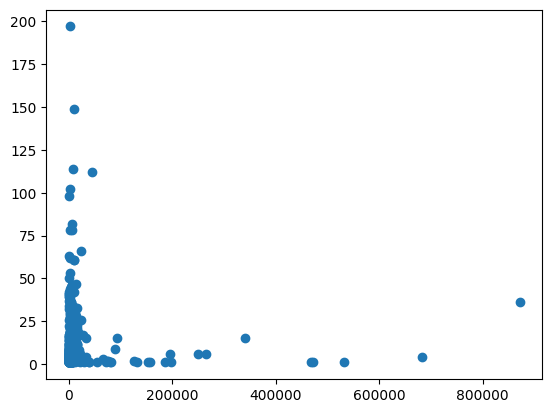

In [98]:
plt.scatter(
    spikes["num_complaints"],
    spikes["recalls_next_year"]
)

In [81]:
device_data

,product_code,YEAR,num_complaints,num_recalls,recalls_next_year,complaint_change
0,FRN,2015,26544,13,17.0,0.0
1,FRN,2016,16385,17,21.0,-10159.0
2,FRN,2017,11935,21,11.0,-4450.0
3,FRN,2018,16062,11,23.0,4127.0
4,FRN,2019,15639,23,43.0,-423.0
5,FRN,2020,92927,43,15.0,77288.0
6,FRN,2021,196629,15,6.0,103702.0
7,FRN,2022,871063,6,36.0,674434.0
8,FRN,2023,164068,36,36.0,-706995.0
9,FRN,2024,56641,36,40.0,-107427.0


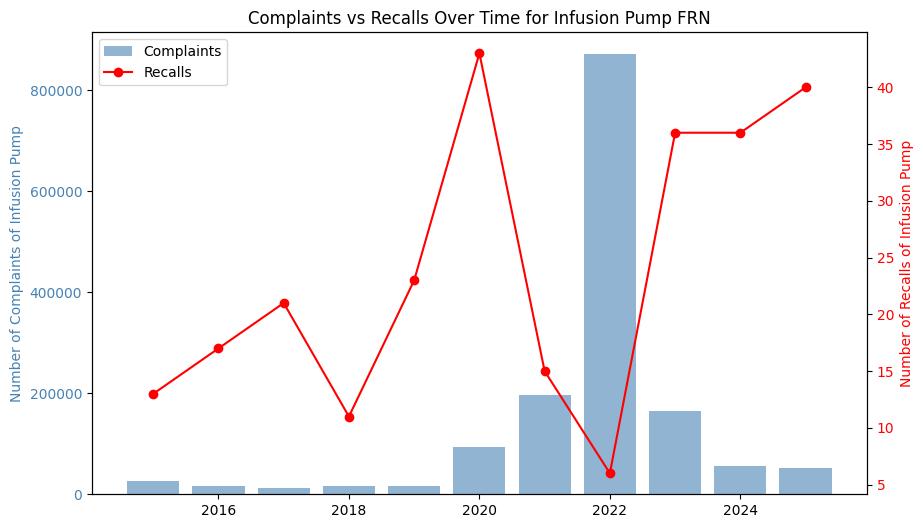

In [92]:
device_data = trend_df1.filter(
    pl.col("product_code") == "FRN"
).to_pandas().sort_values(by='YEAR',ascending=True).fillna(0)

fig, ax1 = plt.subplots(figsize=(10,6))

# Plot complaints on left y-axis

ax1.bar(device_data["YEAR"], device_data["num_complaints"], alpha=0.6, color="steelblue", label="Complaints")
ax1.set_ylabel("Number of Complaints of Infusion Pump", color="steelblue")
ax1.tick_params(axis='y', labelcolor="steelblue")


# Create secondary y-axis for recalls
ax2 = ax1.twinx()
ax2.plot(device_data["YEAR"], device_data["num_recalls"], color="red", marker="o", label="Recalls")
ax2.set_xlabel("Year")
ax2.set_ylabel("Number of Recalls of Infusion Pump", color="red")
ax2.tick_params(axis='y', labelcolor="red")



lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left")

plt.title("Complaints vs Recalls Over Time for Infusion Pump FRN")
plt.show()

In [11]:
unique_subset_d24 = d24.unique(subset=["product_code"])

In [12]:
unique_subset_d24

cfres_id,product_code,product_description,reason_for_recall,device_name,device_class,event_date_initiated,recall_status,similarity_score,FDA_CODE,problem_term,NCIT_CODE,IMDRF_CODE,FDA_mapped
i64,str,str,str,str,str,str,str,f64,i64,str,str,str,bool
100856,"""NEU""","""Bariatric Targ…","""during an fda …","""Marker, Radiog…","""2""","""2011-05-24""","""Terminated""",0.184993,null,null,null,null,false
162852,"""PRH""","""Accelerate Phe…","""the kits may p…","""Positive Blood…","""2""","""2018-03-14""","""Terminated""",0.283626,1227,"""false positive…","""C63147""","""A090804""",true
116142,"""KWR""","""ANSPACH***REF …","""the anspach ef…","""Prosthesis, Sh…","""3""","""2012-11-28""","""Terminated""",0.121094,null,null,null,null,false
68294,"""LIB""","""Remel RapID In…","""failure to pro…","""Device, Genera…","""1""","""2007-10-23""","""Terminated""",0.29994,1514,"""reaction""",null,null,true
180413,"""NAO""","""Siemens N Late…","""negative bias …","""Test, Carbohyd…","""1""","""2020-03-02""","""Terminated""",0.174355,null,null,null,null,false
162889,"""OCS""","""Uretero-reno v…","""potential brea…","""Endoscopic Vid…","""2""","""2018-01-17""","""Terminated""",0.263007,1347,"""lead(s), break…",null,null,true
96406,"""LTK""","""CA15-3 ELISA K…","""product labels…","""Test, Epitheli…","""2""","""2010-12-22""","""Terminated""",0.123696,null,null,null,null,false
86691,"""HTS""","""Stryker Orthop…","""disposable pat…","""Knife, Orthope…","""1""","""2009-11-11""","""Terminated""",0.232193,null,null,null,null,false
38389,"""KLI""","""VITROS Immunod…","""potential for …","""Enzyme Immunoa…","""2""","""2005-03-15""","""Terminated""",0.132073,null,null,null,null,false


In [12]:
unique_subset_d24.columns

['cfres_id',
 'product_code',
 'product_description',
 'reason_for_recall',
 'device_name',
 'device_class',
 'event_date_initiated',
 'recall_status',
 'similarity_score',
 'FDA_CODE',
 'problem_term',
 'NCIT_CODE',
 'IMDRF_CODE',
 'FDA_mapped']

In [13]:
complaints_subset = d13.select([
    "DEVICE_REPORT_PRODUCT_CODE",
    "MDR_REPORT_KEY",
    "GENERIC_NAME",
    "BRAND_NAME",
    "MANUFACTURER_D_NAME",
    "DATE_RECEIVED",
    "TEXT_LENGTH",
    'YEAR'
])

recalls_subset = unique_subset_d24.select([
    "product_code",
    "event_date_initiated",
    "recall_status",
    "reason_for_recall",
    "problem_term"
])




In [14]:
merged_df = complaints_subset.join(
    recalls_subset,
    left_on="DEVICE_REPORT_PRODUCT_CODE",
    right_on="product_code",
    how="inner"
)

In [16]:
merged_df

DEVICE_REPORT_PRODUCT_CODE,MDR_REPORT_KEY,GENERIC_NAME,BRAND_NAME,MANUFACTURER_D_NAME,DATE_RECEIVED,TEXT_LENGTH,event_date_initiated,recall_status,reason_for_recall,problem_term
str,i64,str,str,str,str,i64,str,str,str,str
"""JWH""",2296019,"""KNEE PROSTHESI…","""NEXGEN LCCK FE…","""ZIMMER, INC.""","""2015/07/13""",2058,"""2011-09-23""","""Terminated""","""exactech, inc.…",null
"""DTK""",2686192,"""VENA CAVA FILT…","""G2 FILTER SYST…","""BARD PERIPHERA…","""2015/01/09""",25055,"""2013-03-29""","""Terminated""","""correction to …","""filter"""
"""FDT""",2893201,"""DUODENOSCOPE""","""OLYMPUS EVIS E…","""OLYMPUS MEDICA…","""2015/05/11""",2434,"""2016-01-08""","""Terminated""","""olympus americ…",null
"""NXT""",4068041,"""METAL ON METAL…","""CORMET RESURFA…","""CORIN MEDICAL,…","""2015/02/13""",467,"""2018-05-11""","""Terminated""","""the affected d…","""intended use f…"
"""LRO""",4156242,"""SET UP PACK""","""REGARD""","""RESOURCE OPTIM…","""2015/06/23""",935,"""2011-09-03""","""Terminated""","""some of the co…",null
"""HTO""",4234467,"""DISPOSABLE PAT…","""DISPOSABLE PAT…","""GREATBATCHMEDI…","""2015/04/24""",1179,"""2010-12-23""","""Terminated""","""the firm was n…",null
"""HTO""",4294497,"""REAMER""","""CHAMFER CUTTER…","""GREATBATCH MED…","""2015/01/14""",775,"""2010-12-23""","""Terminated""","""the firm was n…",null
"""LXH""",4307672,"""REAMER HANDLE""","""ACETABULAR REA…","""GREATBATCH MED…","""2015/06/24""",1009,"""2010-03-15""","""Terminated""","""biomet microfi…",null
"""LXH""",4339846,"""FLEXIBLE SHAFT…","""MODULAR FLEXIB…","""GREATBATCH MED…","""2015/02/10""",1095,"""2010-03-15""","""Terminated""","""biomet microfi…",null


In [46]:
merged_df.write_csv("FINALd1234.csv")

In [57]:
test=merged_df.filter(pl.col("DEVICE_REPORT_PRODUCT_CODE") == 'IYN')

DEVICE_REPORT_PRODUCT_CODE,MDR_REPORT_KEY,GENERIC_NAME,BRAND_NAME,MANUFACTURER_D_NAME,DATE_RECEIVED,TEXT_LENGTH,YEAR,event_date_initiated,recall_status,reason_for_recall,problem_term
str,i64,str,str,str,str,i64,i64,str,str,str,str
"""IYN""",4510647,"""SYSTEM, IMAGIN…","""IE 33 ULTRASOU…","""PHILIPS ULTRAS…","""2015/02/12""",737,2015,"""2010-01-06""","""Terminated""","""toshiba americ…",null
"""IYN""",4524783,"""EU-ME1""","""UNIVERSAL ENDO…","""OLYMPUS MEDICA…","""2015/02/10""",1025,2015,"""2010-01-06""","""Terminated""","""toshiba americ…",null
"""IYN""",4530998,"""ULTRASONIC PUL…","""VIVID E9""","""GE VINGMED ULT…","""2015/02/13""",496,2015,"""2010-01-06""","""Terminated""","""toshiba americ…",null
"""IYN""",4531829,"""EU-ME1""","""UNIVERSAL ENDO…","""OLYMPUS MEDICA…","""2015/02/11""",942,2015,"""2010-01-06""","""Terminated""","""toshiba americ…",null
"""IYN""",4550831,"""DIAGNOSTIC ULT…","""ACUSON SC2000 …","""SIEMENS MEDICA…","""2015/02/19""",1099,2015,"""2010-01-06""","""Terminated""","""toshiba americ…",null
"""IYN""",4550832,"""DIAGNOSTIC ULT…","""ACUSON S1000 U…","""SIEMENS MEDICA…","""2015/02/19""",1644,2015,"""2010-01-06""","""Terminated""","""toshiba americ…",null
"""IYN""",4550839,"""DIAGNOSTIC ULT…","""ACUSON S3000 U…","""SIEMENS MEDICA…","""2015/02/19""",894,2015,"""2010-01-06""","""Terminated""","""toshiba americ…",null
"""IYN""",4596682,"""SYSTEM, IMAGIN…","""EPIQ 5G - 7952…","""PHILIPS ULTRAS…","""2015/03/12""",1075,2015,"""2010-01-06""","""Terminated""","""toshiba americ…",null
"""IYN""",4608325,"""PENCIL PROBE, …","""DOPPLER PENCIL…","""PARKS MEDICAL …","""2015/03/03""",314,2015,"""2010-01-06""","""Terminated""","""toshiba americ…",null


In [19]:
reason_recall = test.item(row=0, column="reason_for_recall")
print(reason_recall)


problem_term = test.item(row=0, column="problem_term")
print(problem_term)



there is an error in the pump software where the onetouch(r) ping(r) insulin pump did not allow the user to save changes to the time and date on the pump if those changes were made on february 29, 2012 (leap day).  users who did not attempt to change the time or date on their pump on february 29, 2012 are not affected by this issue.
failure to pump
